##**Data Loading and Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import csv
df = pd.read_csv('whl_2025 - whl_2025.csv')
print(df.head())

  game_id record_id home_team away_team  went_ot home_off_line  \
0  game_1  record_1  thailand  pakistan        0   PP_kill_dwn   
1  game_1  record_2  thailand  pakistan        0    second_off   
2  game_1  record_3  thailand  pakistan        0     first_off   
3  game_1  record_4  thailand  pakistan        0    second_off   
4  game_1  record_5  thailand  pakistan        0    second_off   

  home_def_pairing away_off_line away_def_pairing    home_goalie  ...  \
0      PP_kill_dwn         PP_up            PP_up  player_id_142  ...   
1       second_def    second_off       second_def  player_id_142  ...   
2       second_def    second_off       second_def  player_id_142  ...   
3        first_def    second_off        first_def  player_id_142  ...   
4       second_def     first_off       second_def  player_id_142  ...   

  home_goals  away_assists  away_shots  away_xg  away_max_xg  away_goals  \
0          0             2           9   1.4645       0.2166           1   
1          0

In [ ]:
# Print all columns with missing values
missing_cols = df.columns[df.isna().any()]
print(missing_cols)

# Number of missing values per column
print(df[missing_cols].isna().sum())

Index([], dtype='object')
Series([], dtype: float64)


In [ ]:
df['toi'] = df['toi'] / 60
print(df['toi'])

0        10.480000
1         3.293500
2         0.784333
3         0.743333
4         4.577500
           ...    
25822     2.305500
25823     3.151333
25824     2.599833
25825     3.642333
25826     3.747333
Name: toi, Length: 25827, dtype: float64


##**Context-Based Strength Analysis**

In [ ]:
# es is even strength (excluding PP_up, PP_kill_dwn, empty_net_line)
home_es = df[df['home_off_line'].isin(['first_off', 'second_off'])]
home_es_rate = home_es['home_xg'].sum() / home_es['toi'].sum()

away_es = df[df['away_off_line'].isin(['first_off', 'second_off'])]
away_es_rate = away_es['away_xg'].sum() / away_es['toi'].sum()

es_avg_rate = (home_es_rate + away_es_rate) / 2

print(home_es_rate)
print(away_es_rate)

0.039118031362753304
0.035775450811450095


In [ ]:
# PP_up records
home_pp = df[df['home_off_line'] == 'PP_up']
away_pp = df[df['away_off_line'] == 'PP_up']
pp_rate = (home_pp['home_xg'].sum() + away_pp['away_xg'].sum()) / (home_pp['toi'].sum() + away_pp['toi'].sum())

# Adjust xG
pp_scalar = es_avg_rate / pp_rate

df['home_xg_adj'] = df.apply(lambda row: pp_scalar * row['home_xg'] if row['home_off_line'] == 'PP_up' else row['home_xg'], axis=1)
df['away_xg_adj'] = df.apply(lambda row: pp_scalar * row['away_xg'] if row['away_off_line'] == 'PP_up' else row['away_xg'], axis=1)

print(df['home_xg_adj'])
print(df['away_xg_adj'])

0        0.1754
1        0.0000
2        0.0000
3        0.1211
4        0.1207
          ...  
25822    0.0909
25823    0.0000
25824    0.2171
25825    0.1820
25826    0.1892
Name: home_xg_adj, Length: 25827, dtype: float64
0        0.443702
1        0.092800
2        0.188000
3        0.072700
4        0.076900
           ...   
25822    0.121200
25823    0.093100
25824    0.000000
25825    0.000000
25826    0.115200
Name: away_xg_adj, Length: 25827, dtype: float64


###**Round 0**
`offensive_strength = ∑adjusted_xG_generated / ∑TOI`

`defensive_strength = ∑adjusted_xG_allowed / ∑TOI`

In [ ]:
es_lines = ['first_off', 'second_off']
es_pairings = ['first_def', 'second_def']

# Home offensive accumulation
home_off = df[df['home_off_line'].isin(es_lines)].groupby(['home_team', 'home_off_line']).agg(
    xg=('home_xg_adj', 'sum'),
    toi=('toi', 'sum')
).reset_index().rename(columns={'home_team': 'team', 'home_off_line': 'line'})

# Away offensive accumulation
away_off = df[df['away_off_line'].isin(es_lines)].groupby(['away_team', 'away_off_line']).agg(
    xg=('away_xg_adj', 'sum'),
    toi=('toi', 'sum')
).reset_index().rename(columns={'away_team': 'team', 'away_off_line': 'line'})

# Home defensive accumulation
home_def = df[df['home_def_pairing'].isin(es_pairings)].groupby(['home_team', 'home_def_pairing']).agg(
    xg=('away_xg_adj', 'sum'),
    toi=('toi', 'sum')
).reset_index().rename(columns={'home_team': 'team', 'home_def_pairing': 'line'})

# Away defensive accumulation
away_def = df[df['away_def_pairing'].isin(es_pairings)].groupby(['away_team', 'away_def_pairing']).agg(
    xg=('home_xg_adj', 'sum'),
    toi=('toi', 'sum')
).reset_index().rename(columns={'away_team': 'team', 'away_def_pairing': 'line'})

In [ ]:
# Combine
off_combined = pd.concat([home_off, away_off]).groupby(['team', 'line']).agg(
    xg=('xg', 'sum'),
    toi=('toi', 'sum')
).reset_index()

def_combined = pd.concat([home_def, away_def]).groupby(['team', 'line']).agg(
    xg=('xg', 'sum'),
    toi=('toi', 'sum')
).reset_index()

off_combined['strength'] = off_combined['xg'] / off_combined['toi']
def_combined['strength'] = def_combined['xg'] / def_combined['toi']
print(off_combined.head())
print(def_combined.head())

     team        line       xg          toi  strength
0  brazil   first_off  81.0273  1812.383333  0.044708
1  brazil  second_off  81.7372  1791.650167  0.045621
2  canada   first_off  74.0168  1878.979833  0.039392
3  canada  second_off  70.4763  1808.112000  0.038978
4   china   first_off  79.6366  1914.356333  0.041600
     team        line       xg          toi  strength
0  brazil   first_def  51.8563  1817.003333  0.028539
1  brazil  second_def  70.6046  1787.030167  0.039509
2  canada   first_def  70.2756  1869.541833  0.037590
3  canada  second_def  73.1336  1817.550000  0.040237
4   china   first_def  62.6136  1929.034333  0.032459


###**Round 1**
`offensive_strength = ∑adjusted_xG_generated / ∑(TOI * opponent_defensive_strength)`

`defensive_strength = ∑adjusted_xG_allowed / ∑(TOI * opponent_offensive_strength)`

In [ ]:
def run_iteration(df, off_strength, def_strength):
    es_filter = (
        df['home_off_line'].isin(es_lines) &
        df['home_def_pairing'].isin(es_pairings) &
        df['away_off_line'].isin(es_lines) &
        df['away_def_pairing'].isin(es_pairings)
    )

    filtered_df = df[es_filter]

    # Convert to dictionaries for fast lookup
    off_dict = {(row.team, row.line): row.strength for row in off_strength.itertuples()}
    def_dict = {(row.team, row.line): row.strength for row in def_strength.itertuples()}

    # Accumulators
    off_xg = {}
    off_toi = {}
    def_xg = {}
    def_toi = {}

    for row in filtered_df.itertuples():
        home_team = row.home_team
        away_team = row.away_team
        home_off = row.home_off_line
        home_def = row.home_def_pairing
        away_off = row.away_off_line
        away_def = row.away_def_pairing
        toi = row.toi
        home_xg = row.home_xg_adj
        away_xg = row.away_xg_adj

        away_def_str = def_dict[(away_team, away_def)]
        home_def_str = def_dict[(home_team, home_def)]
        away_off_str = off_dict[(away_team, away_off)]
        home_off_str = off_dict[(home_team, home_off)]

        off_xg[(home_team, home_off)] = off_xg.get((home_team, home_off), 0) + home_xg
        off_toi[(home_team, home_off)] = off_toi.get((home_team, home_off), 0) + toi * away_def_str

        off_xg[(away_team, away_off)] = off_xg.get((away_team, away_off), 0) + away_xg
        off_toi[(away_team, away_off)] = off_toi.get((away_team, away_off), 0) + toi * home_def_str

        def_xg[(home_team, home_def)] = def_xg.get((home_team, home_def), 0) + away_xg
        def_toi[(home_team, home_def)] = def_toi.get((home_team, home_def), 0) + toi * away_off_str

        def_xg[(away_team, away_def)] = def_xg.get((away_team, away_def), 0) + home_xg
        def_toi[(away_team, away_def)] = def_toi.get((away_team, away_def), 0) + toi * home_off_str

    off_strength['new_strength'] = off_strength.apply(
        lambda row: off_xg.get((row['team'], row['line']), 0) / off_toi.get((row['team'], row['line']), 1), axis=1
    )

    def_strength['new_strength'] = def_strength.apply(
        lambda row: def_xg.get((row['team'], row['line']), 0) / def_toi.get((row['team'], row['line']), 1), axis=1
    )

    return off_strength, def_strength

In [ ]:
new_off, new_def = run_iteration(df, off_combined, def_combined)
print(new_off.head())
print(new_def.head())

     team        line       xg          toi  strength  new_strength
0  brazil   first_off  81.0273  1812.383333  0.044708      1.157121
1  brazil  second_off  81.7372  1791.650167  0.045621      1.181466
2  canada   first_off  74.0168  1878.979833  0.039392      1.014511
3  canada  second_off  70.4763  1808.112000  0.038978      1.001145
4   china   first_off  79.6366  1914.356333  0.041600      1.063882
     team        line       xg          toi  strength  new_strength
0  brazil   first_def  51.8563  1817.003333  0.028539      0.698611
1  brazil  second_def  70.6046  1787.030167  0.039509      0.969845
2  canada   first_def  70.2756  1869.541833  0.037590      0.953270
3  canada  second_def  73.1336  1817.550000  0.040237      1.031123
4   china   first_def  62.6136  1929.034333  0.032459      0.868294


In [ ]:
# TOI weighted offensive and defensive strength per team
team_off = new_off.groupby('team').apply(
    lambda x: (x['new_strength'] * x['toi']).sum() / x['toi'].sum()
).reset_index(name='offensive_strength')

team_def = new_def.groupby('team').apply(
    lambda x: (x['new_strength'] * x['toi']).sum() / x['toi'].sum()
).reset_index(name='defensive_strength')

# Merge and calculate net strength
team_strength = team_off.merge(team_def, on='team')
team_strength['net_strength'] = team_strength['offensive_strength'] + 1/team_strength['defensive_strength']

# Rank descending
team_strength = team_strength.sort_values('net_strength', ascending=False).reset_index(drop=True)
team_strength.index += 1

print(team_strength[['team', 'net_strength']])

            team  net_strength
1         brazil      2.369560
2       thailand      2.354528
3       pakistan      2.340250
4         mexico      2.251567
5    south_korea      2.169803
6      guatemala      2.109841
7          china      2.108129
8           peru      2.056365
9    netherlands      2.039504
10        serbia      2.022749
11          oman      2.020660
12        canada      2.016379
13            uk      1.986442
14        rwanda      1.986384
15       morocco      1.970912
16   new_zealand      1.967669
17        panama      1.955186
18       iceland      1.949776
19         india      1.936150
20      ethiopia      1.926370
21        france      1.884418
22           usa      1.871299
23       germany      1.870108
24   switzerland      1.868110
25  saudi_arabia      1.859471
26     singapore      1.847462
27       vietnam      1.832488
28   philippines      1.759501
29           uae      1.739865
30     indonesia      1.707189
31    kazakhstan      1.678122
32      

/tmp/ipykernel_739/4163717507.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_off = new_off.groupby('team').apply(
/tmp/ipykernel_739/4163717507.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_def = new_def.groupby('team').apply(


##**Offensive Disparity**

In [ ]:
# Pivot so each team has first_off and second_off in columns
pivot = (
    off_combined
    .pivot(index="team", columns="line", values="strength")
)

# Create ratio column
pivot["ratio"] = pivot["first_off"]*pivot["second_off"]

# Sort descending and get top 10
top10 = (
    pivot
    .sort_values("ratio", ascending=False)
    .head(10)
    .reset_index()[["team", "ratio"]]
)

top10

line,team,ratio
0,pakistan,0.002361
1,thailand,0.002276
2,brazil,0.002040
3,serbia,0.001951
4,south_korea,0.001842
5,uk,0.001748
6,oman,0.001711
7,mexico,0.001708
8,china,0.001645
9,guatemala,0.001592


In [ ]:
# Reset index so team becomes a column
ratio_df = pivot.reset_index()[["team", "ratio"]]

# Merge with team_strength
merged = ratio_df.merge(team_strength, on="team", how="inner")
print(merged)

            team     ratio  offensive_strength  defensive_strength  \
0         brazil  0.002040            1.169223            0.833100   
1         canada  0.001535            1.007957            0.991648   
2          china  0.001645            1.041049            0.937136   
3       ethiopia  0.001511            1.004470            1.084717   
4         france  0.001340            0.955115            1.076075   
5        germany  0.001365            0.956878            1.095015   
6      guatemala  0.001592            1.041458            0.935994   
7        iceland  0.001390            0.975394            1.026291   
8          india  0.001381            0.962838            1.027421   
9      indonesia  0.000941            0.794894            1.096137   
10    kazakhstan  0.000772            0.709723            1.032633   
11        mexico  0.001708            1.062538            0.841022   
12      mongolia  0.000717            0.689018            1.123137   
13       morocco  0.

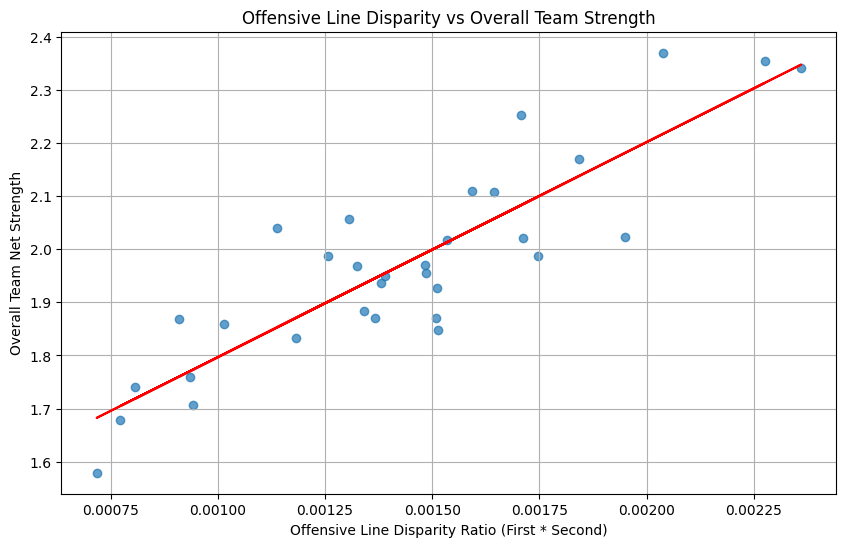

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

m, b = np.polyfit(merged["ratio"], merged["net_strength"], 1)

plt.figure(figsize=(10, 6))
plt.scatter(merged["ratio"], merged["net_strength"], alpha=0.7)
plt.plot(
    merged["ratio"],
    m * merged["ratio"] + b,
    color="red"
)

plt.xlabel("Offensive Line Disparity Ratio (First * Second)")
plt.ylabel("Overall Team Net Strength")
plt.title("Offensive Line Disparity vs Overall Team Strength")

plt.grid(True)
plt.show()

##**Logistic Regression**

In [ ]:
homeG = df.groupby(['game_id', 'home_team'])['home_goals'].sum().reset_index()
awayG = df.groupby(['game_id', 'away_team'])['away_goals'].sum().reset_index()

# Calculate win for home team
match_results = homeG.merge(awayG, on='game_id')
match_results['home_win'] = (match_results['home_goals'] > match_results['away_goals']).astype(int)

print(match_results.head())

     game_id    home_team  home_goals    away_team  away_goals  home_win
0     game_1     thailand           1     pakistan           3         0
1    game_10  switzerland           4   kazakhstan           3         1
2   game_100       serbia           4       rwanda           5         0
3  game_1000       brazil           5  netherlands           0         1
4  game_1001        india           2      morocco           3         0


In [ ]:
match_results = match_results.merge(
    team_strength[['team', 'offensive_strength', 'defensive_strength']].rename(columns={
        'team': 'home_team',
        'offensive_strength': 'home_off_strength',
        'defensive_strength': 'home_def_strength'
    }),
    on='home_team'
).merge(
    team_strength[['team', 'offensive_strength', 'defensive_strength']].rename(columns={
        'team': 'away_team',
        'offensive_strength': 'away_off_strength',
        'defensive_strength': 'away_def_strength'
    }),
    on='away_team'
)
print(match_results.head())

     game_id    home_team  home_goals    away_team  away_goals  home_win  \
0     game_1     thailand           1     pakistan           3         0   
1    game_10  switzerland           4   kazakhstan           3         1   
2   game_100       serbia           4       rwanda           5         0   
3  game_1000       brazil           5  netherlands           0         1   
4  game_1001        india           2      morocco           3         0   

   home_off_strength  home_def_strength  away_off_strength  away_def_strength  
0           1.216072           0.878383           1.251436           0.918430  
1           0.772477           0.912714           0.709723           1.032633  
2           1.143517           1.137357           0.915706           0.933987  
3           1.169223           0.833100           0.860161           0.847930  
4           0.962838           1.027421           0.985892           1.015208  


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

match_results['home_advantage'] = 1
X = match_results[['home_off_strength', 'home_def_strength', 'away_off_strength', 'away_def_strength', 'home_advantage']]
y = match_results['home_win']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train
model = LogisticRegression()
model.fit(X_train, y_train)
# Eval
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss: {log_loss(y_test, y_prob):.4f}")

Accuracy: 0.5703
Log Loss: 0.6723


In [ ]:
upcoming_matches = [
    ('brazil', 'kazakhstan'),
    ('netherlands', 'mongolia'),
    ('peru', 'rwanda'),
    ('thailand', 'oman'),
    ('pakistan', 'germany'),
    ('india', 'usa'),
    ('panama', 'switzerland'),
    ('iceland', 'canada'),
    ('china', 'france'),
    ('philippines', 'morocco'),
    ('ethiopia', 'saudi_arabia'),
    ('singapore', 'new_zealand'),
    ('guatemala', 'south_korea'),
    ('uk', 'mexico'),
    ('vietnam', 'serbia'),
    ('indonesia', 'uae')
]

In [ ]:
import pandas as pd

# Build a per-team lookup table from your match_results
team_strength = pd.concat([
    match_results[['home_team', 'home_off_strength', 'home_def_strength']].rename(
        columns={'home_team':'team','home_off_strength':'off_strength','home_def_strength':'def_strength'}
    ),
    match_results[['away_team', 'away_off_strength', 'away_def_strength']].rename(
        columns={'away_team':'team','away_off_strength':'off_strength','away_def_strength':'def_strength'}
    )
]).groupby('team').last().reset_index()

# Create prediction dataframe for upcoming matches
predict_df = pd.DataFrame([
    {
        "home_team": h,
        "away_team": a,
        "home_off_strength": team_strength.loc[team_strength.team==h, "off_strength"].values[0],
        "home_def_strength": team_strength.loc[team_strength.team==h, "def_strength"].values[0],
        "away_off_strength": team_strength.loc[team_strength.team==a, "off_strength"].values[0],
        "away_def_strength": team_strength.loc[team_strength.team==a, "def_strength"].values[0],
        "home_advantage": 1
    }
    for h, a in upcoming_matches
])

# Predict
X_upcoming = predict_df[["home_off_strength", "home_def_strength", "away_off_strength", "away_def_strength", "home_advantage"]]
predict_df["home_win_probability"] = model.predict_proba(X_upcoming)[:, 1]
predict_df["predicted_home_win"] = model.predict(X_upcoming)

predict_df[["home_team","away_team","home_win_probability","predicted_home_win"]]

,home_team,away_team,home_win_probability,predicted_home_win
0,brazil,kazakhstan,0.692074,1
1,netherlands,mongolia,0.673338,1
2,peru,rwanda,0.576330,1
3,thailand,oman,0.630342,1
4,pakistan,germany,0.656942,1
5,india,usa,0.593744,1
6,panama,switzerland,0.562725,1
7,iceland,canada,0.544036,1
8,china,france,0.615362,1
9,philippines,morocco,0.524412,1


##**Monte Carlo**

In [ ]:
# expected goals modeling
avg_goals_per_game = (match_results['home_goals'].mean() + match_results['away_goals'].mean())
scaling_factor = (avg_goals_per_game / 2)
print(f"Scaling factor: {scaling_factor:.4f}")
print(f"Avg GPG: {avg_goals_per_game:.4f}")

Scaling factor: 2.8788
Avg GPG: 5.7576


In [ ]:
def predict_match(home_team, away_team, n_simulations=10000):
    home = team_strength[team_strength['team'] == home_team].iloc[0]
    away = team_strength[team_strength['team'] == away_team].iloc[0]

    expected_home = (avg_goals_per_game / 2) + home['net_strength']  * scaling_factor
    expected_away = (avg_goals_per_game / 2) + away['net_strength'] * scaling_factor
    expected_home = max(expected_home, 0.1)
    expected_away = max(expected_away, 0.1)

    home_goals = np.random.poisson(expected_home, n_simulations)
    away_goals = np.random.poisson(expected_away, n_simulations)

    home_wins = (home_goals > away_goals).sum() / n_simulations
    away_wins = (away_goals > home_goals).sum() / n_simulations
    draws = (home_goals == away_goals).sum() / n_simulations

    print(f"  {home_team.upper()} vs {away_team.upper()}")
    print(f"  Home win:  {home_wins:.1%}")
    print(f"  Away win:  {away_wins:.1%}")
    print(f"  Draw:  {draws:.1%}")

In [ ]:
for home, away in upcoming_matches:
    predict_match(home, away)
    print()

KeyError: 'net_strength'